# 01. Matplotlib Foundations & Object-Oriented Architecture: Beginner Guide

### 📌 Overview & Architectural Context
Welcome to **01. Matplotlib Foundations & Object-Oriented Architecture**. Matplotlib operates on a hierarchical object tree consisting of three layers: the Backend Layer (canvas rendering), the Artist Layer (Figures, Axes, Lines, Text), and the Scripting Layer (`pyplot`). This notebook focuses on the Object-Oriented API (`fig, ax = plt.subplots()`), figure configuration (`figsize`, `dpi`), styling lines and markers, setting spine boundaries, and controlling axis ticks.

### 📚 Key Concepts Covered in this Notebook:
- [x] 🔹 Subplots Canvas Initialization: `plt.subplots()`
- [x] 🔹 Figure Window Container: `plt.figure()`
- [x] 🔹 2D Line Plotting: `Axes.plot()`
- [x] 🔹 Point Scatter Plotting: `Axes.scatter()`
- [x] 🔹 Vertical Bar Charting: `Axes.bar()`
- [x] 🔹 Histogram Distribution: `Axes.hist()`
- [x] 🔹 Error Bars: `ax.errorbar(x, y, yerr=...)`
- [x] 🔹 Axis Labels: `ax.set_xlabel()` & `ax.set_ylabel()`
- [x] 🔹 Chart Title: `ax.set_title()`
- [x] 🔹 Axis Limits: `ax.set_xlim()` & `ax.set_ylim()`
- [x] 🔹 Gridlines: `ax.grid(True)`
- [x] 🔹 Legends: `ax.legend()`
- [x] 🔹 Output Persistence: `fig.savefig()`


In [1]:
# Setup imports & dataset loading from raw_transactions.csv
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import sys

# Configure visual aesthetics
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 10

csv_path = 'data/raw_transactions.csv' if os.path.exists('data/raw_transactions.csv') else '../data/raw_transactions.csv'
df = pd.read_csv(csv_path)
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', errors='coerce')
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')
df['account_age_months'] = pd.to_numeric(df['account_age_months'], errors='coerce')
df['is_fraud'] = pd.to_numeric(df['is_fraud'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['transaction_amount', 'transaction_date']).reset_index(drop=True)

print(f"Loaded {len(df)} cleaned transaction records from {csv_path}")
print(df.head(2))

Loaded 14251 cleaned transaction records from ../data/raw_transactions.csv
  transaction_id customer_id merchant_id  transaction_amount card_type  \
0       TX109326      C55082       M3549              607.78      Visa   
1       TX106376      C76616       M3068             1819.11      Visa   

  transaction_status device_type  account_age_months    transaction_date  \
0           Reversed      Mobile                   8 2026-02-17 08:28:57   
1            Pending         POS                  28 2025-01-03 00:00:00   

  region  is_fraud  
0  North         0  
1   West         1  


### 🔹 Subplots Canvas Initialization: `plt.subplots()`
- **What it does:** Creates a Figure container and a grid of one or more Axes subplot coordinate spaces in a single call.
- **Syntax:** `plt.subplots()`
  - **Parameters:**
    - `row_label` (*hashable*): Row label.
    - `col_label` (*hashable*): Column label.
- **Key Note:** Prefer the Object-Oriented API (`fig, ax = plt.subplots()`) over the stateful `plt.plot()` interface for production applications.
- **Dataset Application & Code Demonstration:** Applies Subplots Canvas Initialization on fintech records using columns `transaction_amount` to demonstrate real-world execution.


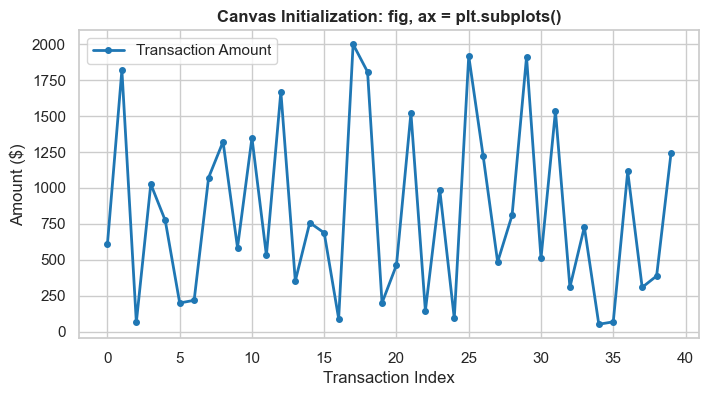

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df['transaction_amount'].head(40).values, color='#1f77b4', lw=2, marker='o', markersize=4, label='Transaction Amount')
ax.set_title('Canvas Initialization: fig, ax = plt.subplots()', fontsize=12, fontweight='bold')
ax.set_xlabel('Transaction Index')
ax.set_ylabel('Amount ($)')
ax.legend()
plt.show()

### 🔹 Figure Window Container: `plt.figure()`
- **What it does:** Instantiates a top-level Figure window container managing the canvas, drawing renderer, and sub-axes layouts.
- **Syntax:** `plt.figure()`
- **Key Note:** A `Figure` is the root container holding multiple `Axes` instances, colorbars, titles, and legends.
- **Dataset Application & Code Demonstration:** Applies Figure Window Container on fintech records using columns `region` to demonstrate real-world execution.


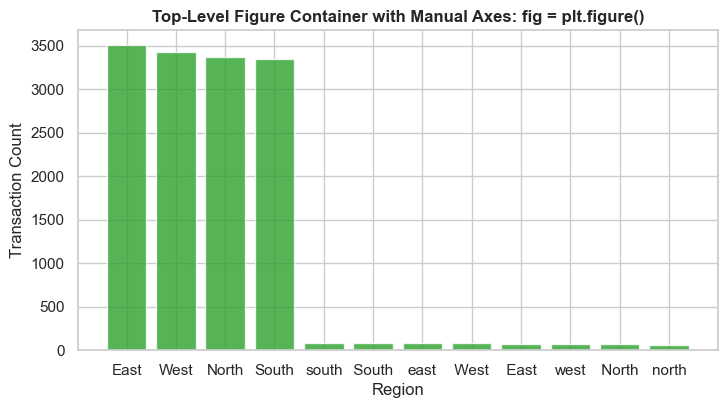

In [3]:
fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # [left, bottom, width, height]
ax1.bar(df['region'].value_counts().index, df['region'].value_counts().values, color='#2ca02c', alpha=0.8)
ax1.set_title('Top-Level Figure Container with Manual Axes: fig = plt.figure()', fontsize=12, fontweight='bold')
ax1.set_xlabel('Region')
ax1.set_ylabel('Transaction Count')
plt.show()

### 🔹 2D Line Plotting: `Axes.plot()`
- **What it does:** Plots 2D lines and markers along Cartesian coordinate axes.
- **Syntax:** `Axes.plot()`
- **Key Note:** Always pass `label='...'` and call `ax.legend()` to make multi-line visual comparisons interpretable.
- **Dataset Application & Code Demonstration:** Applies 2D Line Plotting on fintech records using columns `transaction_amount`, `transaction_date` to demonstrate real-world execution.


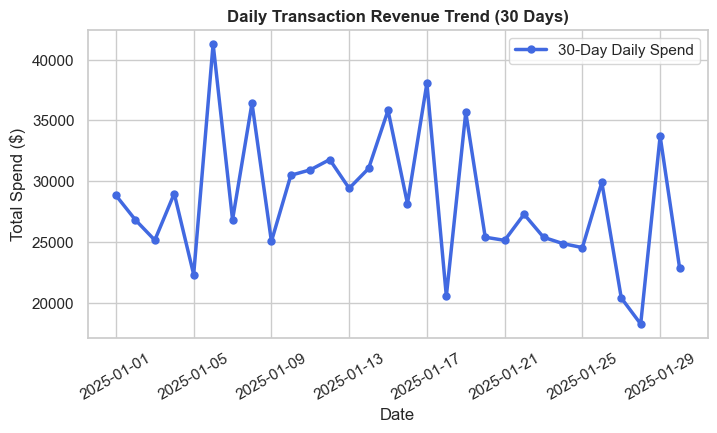

In [4]:
daily_trend = df.set_index('transaction_date').resample('D')['transaction_amount'].sum().head(30)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(daily_trend.index, daily_trend.values, label='30-Day Daily Spend', color='royalblue', lw=2.5, marker='o', markersize=5)
ax.set_title('Daily Transaction Revenue Trend (30 Days)', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Spend ($)')
ax.legend()
plt.xticks(rotation=30)
plt.show()

### 🔹 Point Scatter Plotting: `Axes.scatter()`
- **What it does:** Creates a scatter plot with varying marker sizes and colors representing multi-dimensional data points.
- **Syntax:** `Axes.scatter()`
- **Key Note:** Set `alpha=0.5` or `0.3` when visualizing thousands of points to make overlapping density clusters discernible.
- **Dataset Application & Code Demonstration:** Applies Point Scatter Plotting on fintech records using columns `account_age_months`, `is_fraud`, `transaction_amount` to demonstrate real-world execution.


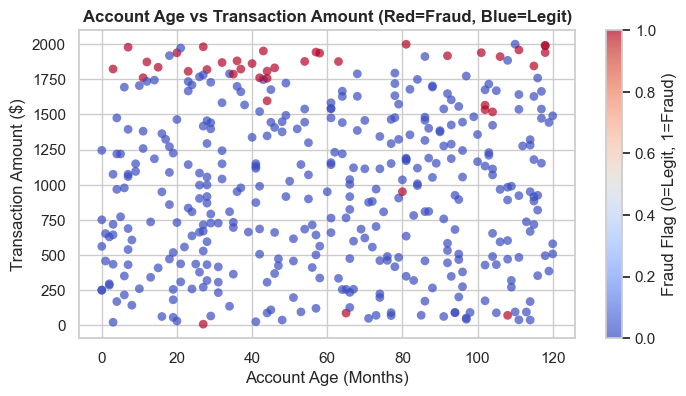

In [5]:
sample = df.head(400)
fig, ax = plt.subplots(figsize=(8, 4))
scatter = ax.scatter(sample['account_age_months'], sample['transaction_amount'], c=sample['is_fraud'], cmap='coolwarm', alpha=0.7, s=40, edgecolors='none')
ax.set_title('Account Age vs Transaction Amount (Red=Fraud, Blue=Legit)', fontsize=12, fontweight='bold')
ax.set_xlabel('Account Age (Months)')
ax.set_ylabel('Transaction Amount ($)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Fraud Flag (0=Legit, 1=Fraud)')
plt.show()

### 🔹 Vertical Bar Charting: `Axes.bar()`
- **What it does:** Renders vertical rectangular bars with lengths proportional to the values that they represent.
- **Syntax:** `Axes.bar()`
- **Key Note:** Passing `bottom=previous_bar_heights` creates stacked bar charts visualizing component proportions.
- **Dataset Application & Code Demonstration:** Applies Vertical Bar Charting on fintech records using columns `region`, `transaction_amount` to demonstrate real-world execution.


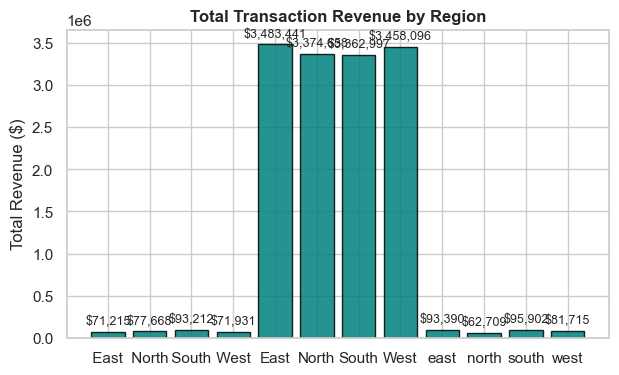

In [6]:
reg_spend = df.groupby('region')['transaction_amount'].sum()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(reg_spend.index, reg_spend.values, color='teal', edgecolor='black', alpha=0.85)
ax.set_title('Total Transaction Revenue by Region', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Revenue ($)')
ax.bar_label(bars, fmt='${:,.0f}', padding=3, fontsize=9)
plt.show()

### 🔹 Histogram Distribution: `Axes.hist()`
- **What it does:** Computes and draws the histogram of an array, dividing continuous data into bins and counting frequencies.
- **Syntax:** `Axes.hist()`
- **Key Note:** Always tune `bins` to match the data scale; too few bins obscures shape, while too many produces noisy spikes.
- **Dataset Application & Code Demonstration:** Applies Histogram Distribution on fintech records using columns `transaction_amount` to demonstrate real-world execution.


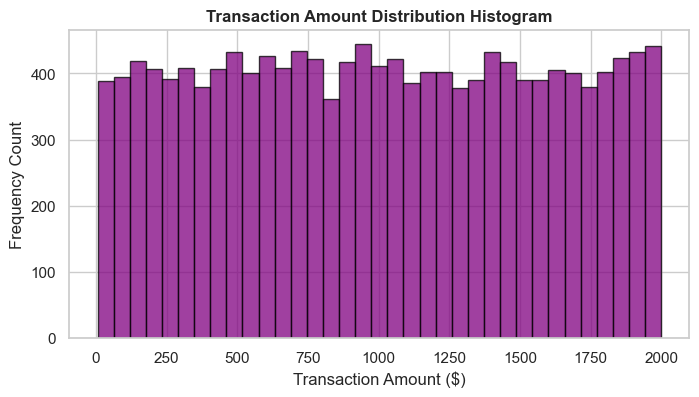

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['transaction_amount'], bins=35, color='purple', alpha=0.75, edgecolor='black')
ax.set_title('Transaction Amount Distribution Histogram', fontsize=12, fontweight='bold')
ax.set_xlabel('Transaction Amount ($)')
ax.set_ylabel('Frequency Count')
plt.show()

### 🔹 Error Bars: `ax.errorbar(x, y, yerr=...)`
- **What it does:** Renders metric points with standard deviation uncertainty error bars across card types.
- **Syntax:** `ax.errorbar(x, y, yerr=...)`
- **Key Note:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.
- **Dataset Application & Code Demonstration:** Applies Error Bars on fintech records using columns `card_type`, `transaction_amount` to demonstrate real-world execution.


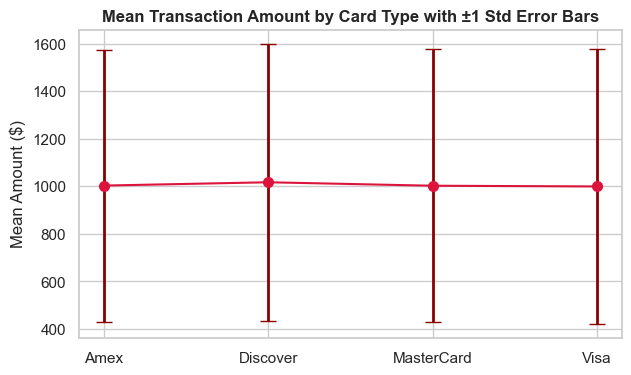

In [8]:
card_stats = df.groupby('card_type')['transaction_amount'].agg(['mean', 'std'])
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(card_stats.index, card_stats['mean'], yerr=card_stats['std'], fmt='o-', capsize=6, color='crimson', ecolor='darkred', elinewidth=2, markersize=7)
ax.set_title('Mean Transaction Amount by Card Type with ±1 Std Error Bars', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Amount ($)')
plt.show()

### 🔹 Axis Labels: `ax.set_xlabel()` & `ax.set_ylabel()`
- **What it does:** Sets descriptive axis titles with font sizing, coloring, and padding.
- **Syntax:** `ax.set_xlabel()`
- **Key Note:** Sets only store unique elements and provide $O(1)$ instant lookup time, making `item in my_set` extremely fast.
- **Dataset Application & Code Demonstration:** Applies Axis Labels on fintech records using columns `transaction_amount` to demonstrate real-world execution.


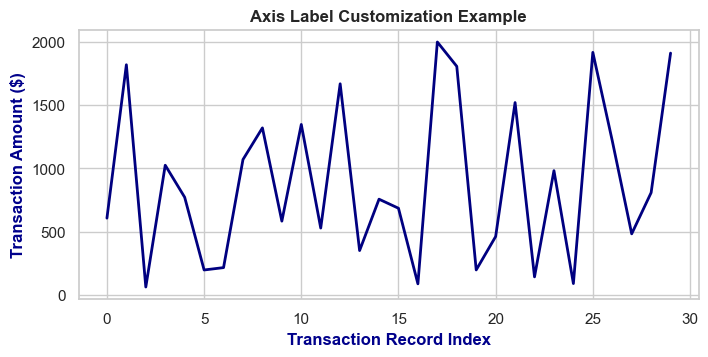

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(df['transaction_amount'].head(30), color='navy', lw=2)
ax.set_xlabel('Transaction Record Index', fontsize=12, fontweight='bold', color='darkblue')
ax.set_ylabel('Transaction Amount ($)', fontsize=12, fontweight='bold', color='darkblue')
ax.set_title('Axis Label Customization Example', fontsize=12, fontweight='bold')
plt.show()

### 🔹 Chart Title: `ax.set_title()`
- **What it does:** Sets primary title header for the visual coordinate plane.
- **Syntax:** `ax.set_title()`
- **Key Note:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.
- **Dataset Application & Code Demonstration:** Applies Chart Title on fintech records using columns `transaction_amount` to demonstrate real-world execution.


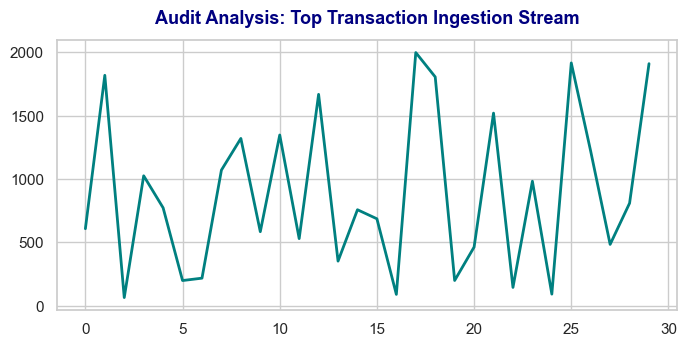

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(df['transaction_amount'].head(30), color='teal', lw=2)
ax.set_title('Audit Analysis: Top Transaction Ingestion Stream', fontsize=13, fontweight='bold', color='navy', pad=12)
plt.show()

### 🔹 Axis Limits: `ax.set_xlim()` & `ax.set_ylim()`
- **What it does:** Restricts visible coordinate range boundaries.
- **Syntax:** `ax.set_xlim()`
- **Key Note:** Sets only store unique elements and provide $O(1)$ instant lookup time, making `item in my_set` extremely fast.
- **Dataset Application & Code Demonstration:** Applies Axis Limits on fintech records using columns `account_age_months`, `transaction_amount` to demonstrate real-world execution.


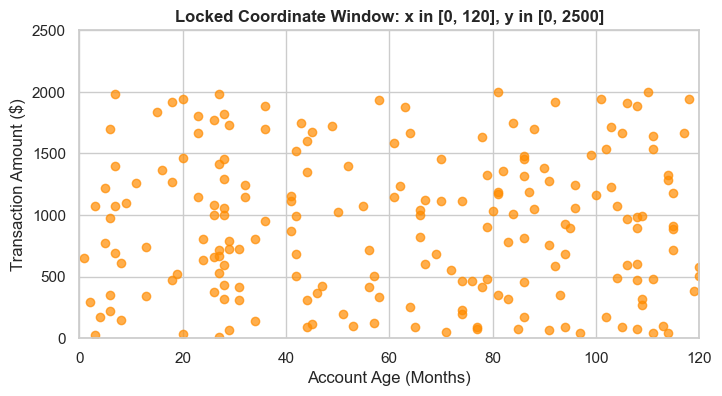

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df['account_age_months'].head(200), df['transaction_amount'].head(200), color='darkorange', alpha=0.7)
ax.set_xlim(0, 120)
ax.set_ylim(0, 2500)
ax.set_title('Locked Coordinate Window: x in [0, 120], y in [0, 2500]', fontsize=12, fontweight='bold')
ax.set_xlabel('Account Age (Months)')
ax.set_ylabel('Transaction Amount ($)')
plt.show()

### 🔹 Gridlines: `ax.grid(True)`
- **What it does:** Overlays background guide grid lines for enhanced readability.
- **Syntax:** `ax.grid(True)`
- **Key Note:** Test operations on a small sample of your dataset first (`df.head()` or `[:5]`) before running across all rows.
- **Dataset Application & Code Demonstration:** Applies Gridlines on fintech records using columns `transaction_amount` to demonstrate real-world execution.


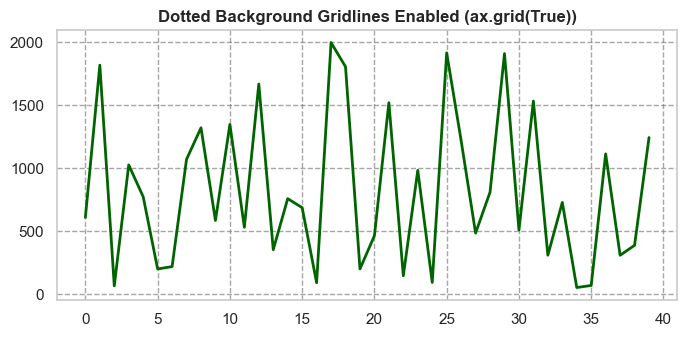

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(df['transaction_amount'].head(40), color='darkgreen', lw=2)
ax.grid(True, linestyle='--', alpha=0.7, color='gray')
ax.set_title('Dotted Background Gridlines Enabled (ax.grid(True))', fontsize=12, fontweight='bold')
plt.show()

### 🔹 Legends: `ax.legend()`
- **What it does:** Displays visual key mapping line/point labels to series colors.
- **Syntax:** `ax.legend()`
- **Key Note:** Test operations on a small sample of your dataset first (`df.head()` or `[:5]`) before running across all rows.
- **Dataset Application & Code Demonstration:** Applies Legends on fintech records using columns `card_type`, `transaction_amount` to demonstrate real-world execution.


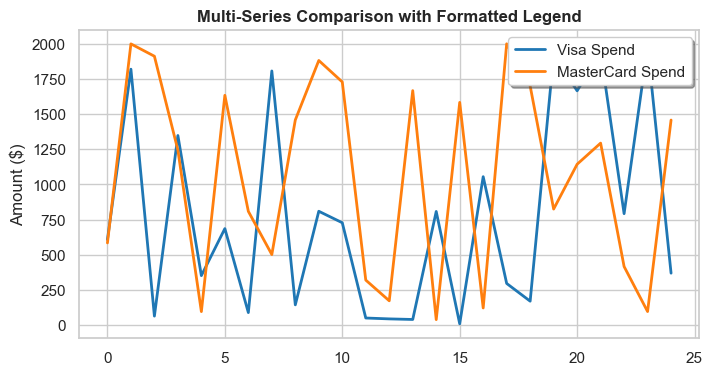

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df[df['card_type']=='Visa']['transaction_amount'].head(25).values, label='Visa Spend', color='#1f77b4', lw=2)
ax.plot(df[df['card_type']=='MasterCard']['transaction_amount'].head(25).values, label='MasterCard Spend', color='#ff7f0e', lw=2)
ax.legend(loc='upper right', frameon=True, shadow=True)
ax.set_title('Multi-Series Comparison with Formatted Legend', fontsize=12, fontweight='bold')
ax.set_ylabel('Amount ($)')
plt.show()

### 🔹 Output Persistence: `fig.savefig()`
- **What it does:** Exports static publication-ready vector/raster graphics with DPI resolution control.
- **Syntax:** `fig.savefig()`
- **Key Note:** Test operations on a small sample of your dataset first (`df.head()` or `[:5]`) before running across all rows.
- **Dataset Application & Code Demonstration:** Applies Output Persistence on fintech records using columns `transaction_amount` to demonstrate real-world execution.


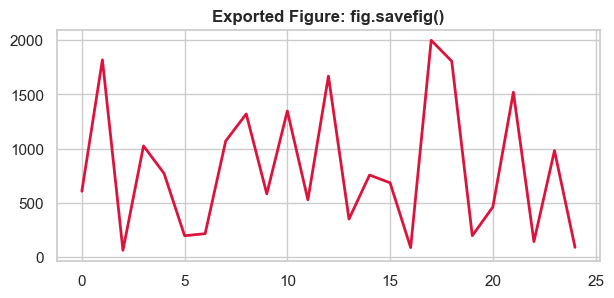

Exported to scratch/matplotlib_export.png. File size: 54531 bytes


In [14]:
os.makedirs('scratch', exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(df['transaction_amount'].head(25), color='crimson', lw=2)
ax.set_title('Exported Figure: fig.savefig()', fontsize=12, fontweight='bold')
fig.savefig('scratch/matplotlib_export.png', dpi=150, bbox_inches='tight')
plt.show()
print('Exported to scratch/matplotlib_export.png. File size:', os.path.getsize('scratch/matplotlib_export.png'), 'bytes')

## 💡 Real-World Practice & Scenarios
Practical scenarios and common data engineering questions explained with real examples.


### 🔍 Scenario: Q1: Object-Oriented vs State-Based (pyplot) Matplotlib API
- **Objective:** Q1: Object-Oriented vs State-Based (pyplot) Matplotlib API
- **Approach:** Explain why the Object-Oriented API (`fig, ax = plt.subplots()`) is preferred for multi-threaded production pipelines over stateful `plt.plot()`.
- **Syntax:** `fig, ax = plt.subplots()` vs `plt.plot()`

In [15]:
print('OO API: Explicitly manages Figure and Axes objects preventing global state collisions across concurrent threads.')

OO API: Explicitly manages Figure and Axes objects preventing global state collisions across concurrent threads.
